# Clustering: Apprendimento Non Supervisionato

## Lezione 1: Introduzione e K-Means

In questa lezione esploriamo il **clustering**, una tecnica di apprendimento non supervisionato che permette di raggruppare dati simili senza avere etichette predefinite.

---
## 1. Setup e Importazioni

In [3]:
# Librerie fondamentali
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Clustering
from sklearn.cluster import KMeans

# Dataset sintetici
from sklearn.datasets import make_blobs, make_moons, make_circles

# Metriche di valutazione
from sklearn.metrics import silhouette_score, silhouette_samples



plt.style.use('seaborn-v0_8-whitegrid')

---
## 2. Supervised vs Unsupervised Learning

Finora abbiamo visto algoritmi di **classificazione** (supervised learning):
- Avevamo **etichette** (y) che ci dicevano la classe corretta
- L'algoritmo imparava a mappare X → y
- Potevamo misurare l'accuracy confrontando predizioni con etichette vere

Nel **clustering** (unsupervised learning):
- **Non abbiamo etichette**
- L'algoritmo deve scoprire strutture nascoste nei dati
- Raggruppa punti "simili" insieme
- La valutazione è più complessa (non c'è una "risposta giusta")

**Casi d'uso tipici:**
- Segmentazione clienti (marketing)
- Raggruppamento documenti/news
- Rilevamento anomalie
- Esplorazione dati prima di costruire modelli supervisionati

---
## 3. Dataset Sintetici per Capire il Clustering

Scikit-learn offre funzioni per generare dataset sintetici, utili per capire come funzionano gli algoritmi.
Queste funzioni sono

- make_blobs
- make_moons
- make_circles

### make_blobs

Genera cluster sferici (o "blob") ben separati. I parametri principali sono:
- n_samples: numero totale di punti
- centers: numero di cluster (o coordinate esatte dei centri)
- cluster_std: deviazione standard, utile per controllare quanto i punti sono "sparsi" attorno al centro. Valori bassi = cluster compatti, valori alti = cluster più diffusi
random_state: seed per riproducibilità
- random_state: seed per riproducibilità

Domanda: Qual è l'algoritmo ideale da utilizzare su questi dati?

### make_moons
Genera due mezzelune intrecciate. I cluster non sono sferici ma hanno una forma curva. I parametri principali sono:
- n_samples: numero totale di punti (divisi equamente tra le due lune)
- noise: quantità di rumore gaussiano aggiunto. Valori bassi = lune pulite, valori alti = più caotiche

Domanda: Qual è l'algoritmo ideale da utilizzare su questi dati?

### make_circles

Genera due cerchi concentrici, un cerchio interno e uno esterno. I parametri principali sono:
- n_samples: numero totale di punti
- noise: rumore gaussiano
- factor: rapporto tra raggio interno ed esterno (0 < factor < 1). Con factor=0.5 il cerchio interno ha raggio metà di quello esterno

Domanda: Qual è l'algoritmo ideale da utilizzare su questi dati?

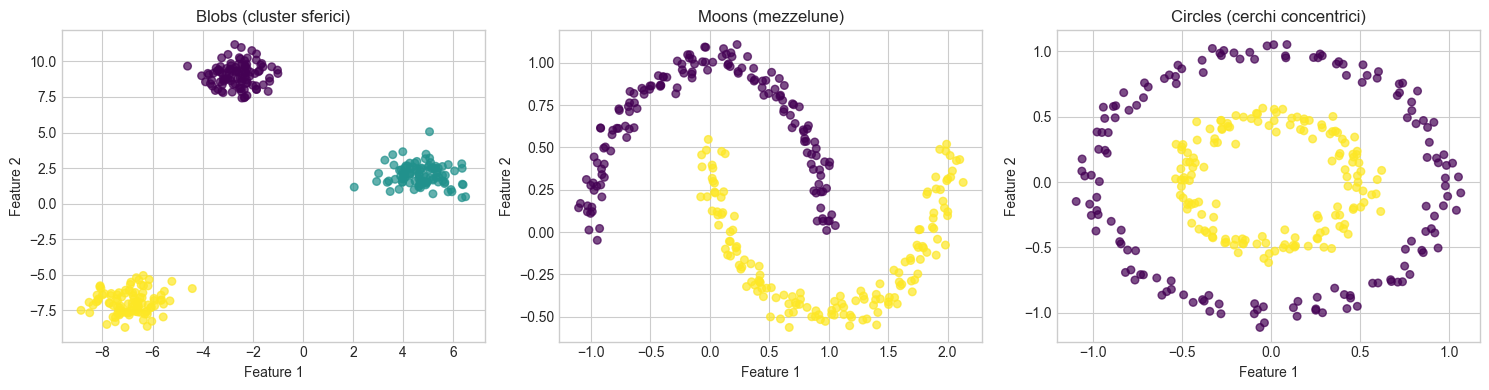

In [4]:
# Generare 3 tipi di dataset sintetici
np.random.seed(42)

# 1. Blobs: cluster sferici ben separati
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

# 2. Moons: due "mezzelune" intrecciate
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

# 3. Circles: cerchi concentrici
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# Visualizzare i dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (X_blobs, y_blobs, 'Blobs (cluster sferici)'),
    (X_moons, y_moons, 'Moons (mezzelune)'),
    (X_circles, y_circles, 'Circles (cerchi concentrici)')
]

for ax, (X, y, title) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=30, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

**Nota:** Qui abbiamo le etichette `y` solo per visualizzazione. Nel clustering reale, **non le avremo**!

---
## 4. K-Means: L'algoritmo di Clustering più Famoso

### 4.1 Come Funziona

K-Means è un algoritmo iterativo che cerca di partizionare i dati in **K cluster**, dove K è scelto dall'utente.

**Algoritmo:**
1. **Inizializzazione:** Scegli K punti casuali come centroidi iniziali
2. **Assegnazione:** Assegna ogni punto al centroide più vicino
3. **Aggiornamento:** Ricalcola i centroidi come media dei punti assegnati
4. **Ripeti** passi 2-3 fino a convergenza (i centroidi non cambiano più)

**Obiettivo:** Minimizzare l'**inerzia** (somma delle distanze al quadrato di ogni punto dal suo centroide)

In [5]:
# Applicare K-Means al dataset blobs
# n_inits specifica quante volte l'algoritmo verrà eseguito con diverse inizializzazioni, il risultato migliore viene scelto
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_blobs)

# Ottenere le etichette predette e i centroidi
labels = kmeans.labels_           # Etichetta del cluster per ogni punto
centroids = kmeans.cluster_centers_  # Coordinate dei centroidi

# Quante iterazioni ha impiegato K-Means per convergere?
n_iter = kmeans.n_iter_

print(f"K-Means ha impiegato {n_iter} iterazioni per convergere.")
print(f"Etichette uniche: {np.unique(labels)}")
print(f"\nCentroidi:\n{centroids}")
print(f"\nInerzia: {kmeans.inertia_:.2f}")

K-Means ha impiegato 2 iterazioni per convergere.
Etichette uniche: [0 1 2]

Centroidi:
[[-2.60842567  9.03771305]
 [-6.88302287 -6.96320924]
 [ 4.72565847  2.00310936]]

Inerzia: 362.79


### Domanda

Dove si trovano le predizioni per i nostri punti?

In [6]:
print(labels.shape)
print(labels)

(300,)
[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0 0 0 2 1 0 1 1 2 2 0 0 0 1 0 1 0 1
 2 1 2 2 0 1 2 0 0 1 2 1 2 2 1 1 0 1 2 1 0 2 0 1 2 2 1 1 2 2 1 1 0 2 1 1 0
 0 1 1 2 0 2 0 0 1 0 2 1 1 0 2 0 1 0 1 0 0 1 1 0 1 1 2 0 2 0 0 0 0 0 2 1 2
 0 0 0 0 2 1 2 1 2 2 2 0 1 1 1 1 0 1 1 0 0 0 0 0 2 2 1 0 1 0 0 1 0 2 2 2 0
 2 0 0 1 2 1 0 2 2 1 1 0 0 1 1 1 0 1 2 0 0 0 0 0 2 0 2 2 2 0 2 2 1 0 1 2 2
 1 2 0 2 2 1 1 2 1 2 2 2 2 0 1 0 0 2 2 0 2 1 1 2 0 0 1 2 2 1 1 1 1 0 1 1 2
 1 1 0 2 1 1 2 0 0 1 0 1 2 2 1 2 1 1 1 2 2 0 1 2 2 2 1 2 1 2 1 2 2 1 2 0 1
 0 0 0 1 0 2 2 1 2 2 0 0 2 2 2 1 1 1 0 0 0 2 2 2 2 1 2 1 2 2 1 0 2 2 0 1 0
 2 0 1 1]


Labels contiene l'etichetta corrisponde al cluster assegnato ad ogni punto

 ### Visualizzare i risultati

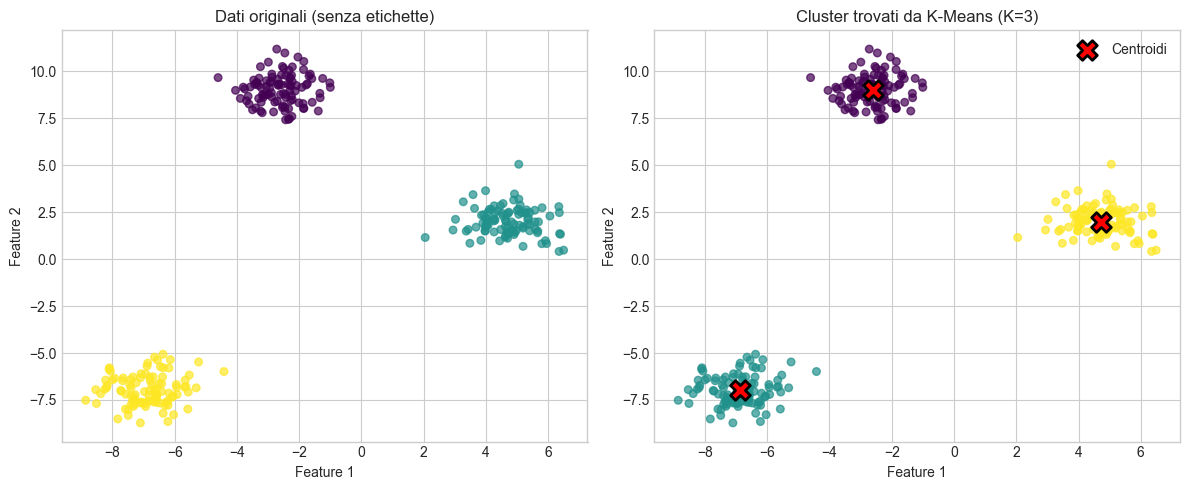

In [7]:
# Visualizzare i risultati
# Creo una figura con una riga e due colonne, dimensioni 12x5 pollici
# Come al solito, fig è l'oggetto figura e axes è un array di assi (sotto-grafici)
# axes[0] è il primo sotto-grafico, axes[1] il secondo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Prima: dati originali (senza sapere i cluster)
# Plotto sulle X X_blobs[:, 0] e sulle Y X_blobs[:, 1]
# Cosa vuol dire [:, 0] e [:, 1]?
# Uso il colore grigio per tutti i punti, dimensione 30, trasparenza 0.5
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', s=30, alpha=0.7)
axes[0].set_title('Dati originali (senza etichette)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Dopo: cluster trovati da K-Means
# Come prima, ma coloro i punti in base alle etichette trovate da K-Means
# Inoltre, sovrappongo i centroidi in rosso con marker 'X', dimensione 200, bordo nero spesso 2
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)
axes[1].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, 
                edgecolors='black', linewidths=2, label='Centroidi')
axes[1].set_title('Cluster trovati da K-Means (K=3)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.2 Predire Nuovi Punti

Una volta addestrato, K-Means può assegnare nuovi punti al cluster più vicino.

In [8]:
# Creare alcuni punti nuovi
new_points = np.array([
    [0, 0],
    [-5, -8],
    [7, 2]
])

# Predire il cluster
predicted_clusters = kmeans.predict(new_points)

print("Nuovi punti e cluster assegnati:")
for point, cluster in zip(new_points, predicted_clusters):
    print(f"  Punto {point} → Cluster {cluster}")

Nuovi punti e cluster assegnati:
  Punto [0 0] → Cluster 2
  Punto [-5 -8] → Cluster 1
  Punto [7 2] → Cluster 2


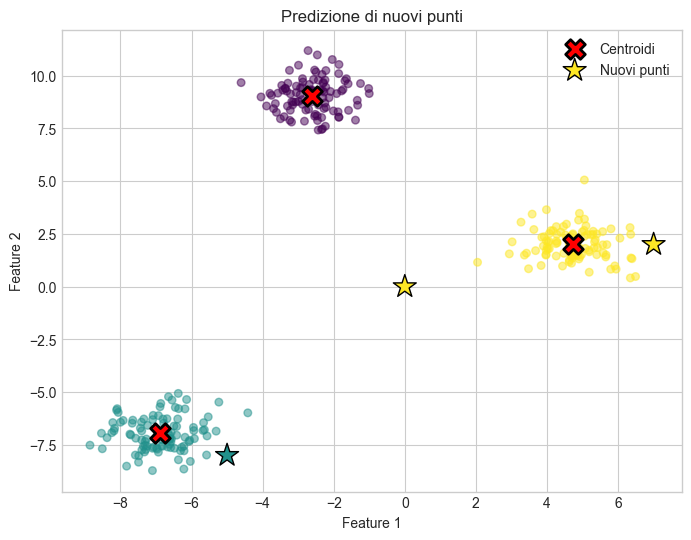

In [9]:
# Visualizzare
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels, cmap='viridis', s=30, alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, 
            edgecolors='black', linewidths=2, label='Centroidi')

plt.scatter(new_points[:, 0], # Coordinate X (Feature 1)
            new_points[:, 1], # Coordinate Y (Feature 2)
            c=predicted_clusters, # Colori in base ai cluster predetti
            cmap='viridis', # mappa di colori da usare
            vmin=0, # valore minimo per la mappa colori
            vmax=2, # valore massimo per la mappa colori
            marker='*', # marker a stella
            s=300,  # dimensione del marker
            edgecolors='black',  # bordo nero
            linewidths=1, # spessore del bordo
            label='Nuovi punti' # etichetta per la legenda
            )
plt.title('Predizione di nuovi punti')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

---
## 5. Il Problema: Come Scegliere K?

K-Means richiede di specificare **in anticipo** il numero di cluster. Ma come sappiamo qual è il K giusto?

### 5.1 Metodo del Gomito (Elbow Method)

L'idea è provare diversi valori di K e osservare come cambia l'**inerzia** (somma delle distanze al quadrato):
- Con K=1, tutti i punti in un solo cluster → inerzia massima
- Con K=n_campioni, ogni punto è un cluster → inerzia = 0
- Cerchiamo il "gomito": il punto dove aumentare K non migliora molto l'inerzia

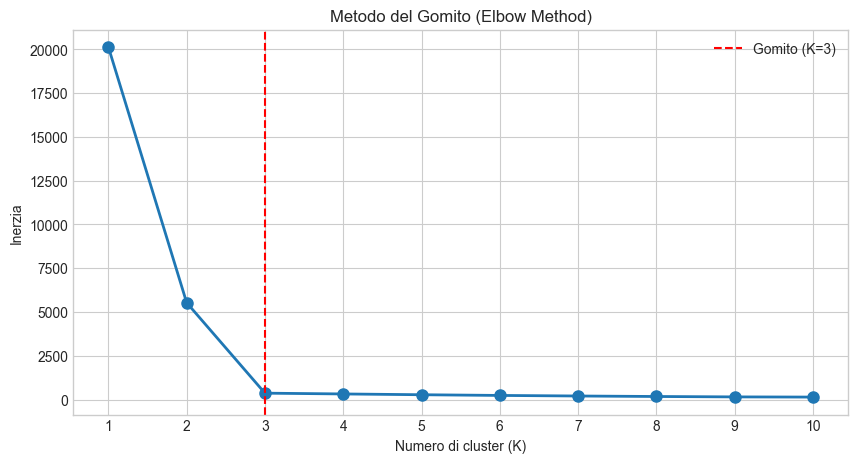

In [10]:
# Calcolare l'inerzia per diversi valori di K
k_values = range(1, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_blobs)
    inertias.append(kmeans.inertia_)

# Plot del gomito
plt.figure(figsize=(10, 5))
# o-b è una format string (o fmt), del tipo [marker][line][color]. Indica punti blu collegati da linee (guardare notes https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)
plt.plot(k_values, inertias, 'o-', linewidth=2, markersize=8)
# disegna una linea verticale rossa tratteggiata al punto K=3, se la volessi orizzontale sarebbe plt.axhline
plt.axvline(x=3, color='r', linestyle='--', label='Gomito (K=3)')
plt.xlabel('Numero di cluster (K)')
plt.ylabel('Inerzia')
plt.title('Metodo del Gomito (Elbow Method)')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

**Interpretazione:** Il "gomito" è a K=3, che corrisponde al numero reale di cluster nel dataset. Dopo K=3, l'inerzia diminuisce lentamente.

### 5.2 Silhouette Score

Il **Silhouette Score** misura quanto bene ogni punto è assegnato al suo cluster.

Per ogni punto i:
- **a(i)** = distanza media dai punti dello stesso cluster (coesione)
- **b(i)** = distanza media dai punti del cluster più vicino (separazione)
- **s(i)** = (b(i) - a(i)) / max(a(i), b(i))

**Interpretazione:**
- s(i) ≈ +1: il punto è ben assegnato (lontano dagli altri cluster)
- s(i) ≈ 0: il punto è al confine tra due cluster
- s(i) ≈ -1: il punto è probabilmente nel cluster sbagliato

Il **Silhouette Score medio** (su tutti i punti) è una misura della qualità complessiva del clustering.

In [11]:
from sklearn.metrics import silhouette_score

# Calcolare il silhouette score per diversi K
k_values = range(2, 11)  # Silhouette richiede almeno 2 cluster
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_blobs)
    
    # metodo equivalente 1
    # kmeans.fit(X_blobs)
    # labels = kmeans.predict(X_blobs)
    
    # metodo equivalente 2
    # kmeans.fit(X_blobs)
    # labels = kmeans.labels_
    
    score = silhouette_score(X_blobs, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.3f}")

K=2: Silhouette Score = 0.721
K=3: Silhouette Score = 0.878
K=4: Silhouette Score = 0.697
K=5: Silhouette Score = 0.503
K=6: Silhouette Score = 0.327
K=7: Silhouette Score = 0.351
K=8: Silhouette Score = 0.367
K=9: Silhouette Score = 0.369
K=10: Silhouette Score = 0.357


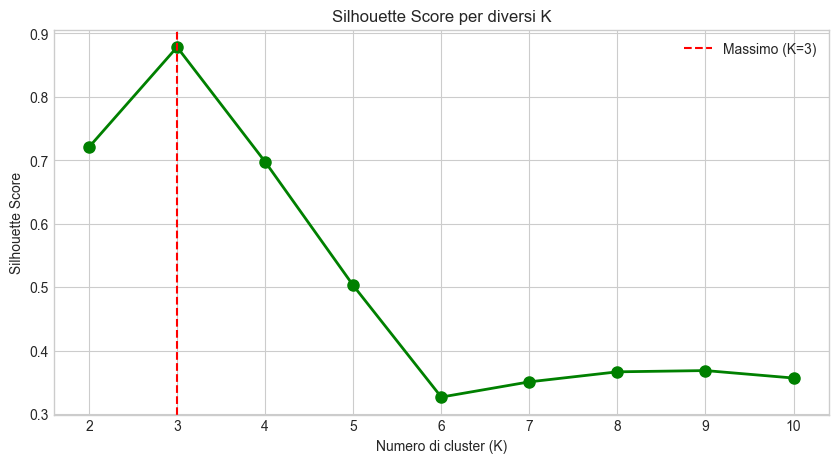

In [12]:
# Plot del silhouette score
plt.figure(figsize=(10, 5))
plt.plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.axvline(x=3, color='r', linestyle='--', label='Massimo (K=3)')
plt.xlabel('Numero di cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per diversi K')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

**Interpretazione:** Il Silhouette Score è massimo a K=3, confermando che è il numero ottimale di cluster.

### 5.3 Silhouette Plot

Possiamo visualizzare il silhouette score di ogni singolo punto per capire la qualità di ogni cluster.

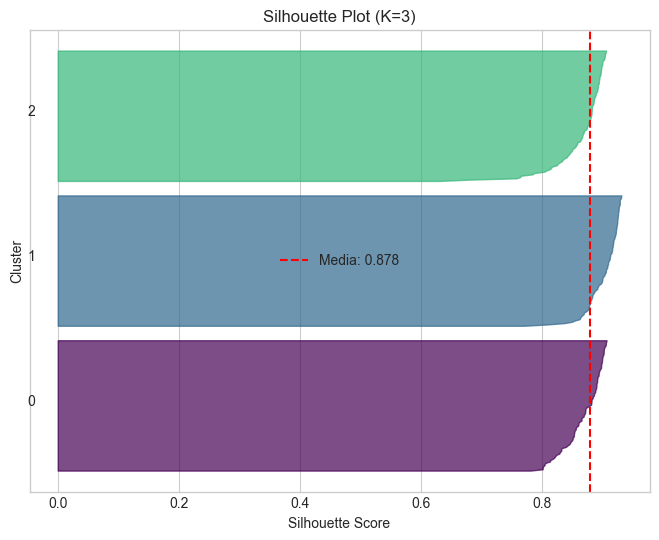

In [14]:
from matplotlib import cm

def plot_silhouette(X, labels, n_clusters):
    """Crea un silhouette plot per visualizzare la qualità dei cluster."""
    
    # Calcolare il silhouette score per ogni campione
    silhouette_vals = silhouette_samples(X, labels)
        
    fig, ax = plt.subplots(figsize=(8, 6))
            
    y_lower = 10
    for i in range(n_clusters):
        # Silhouette scores per il cluster i
        cluster_silhouette_vals = silhouette_vals[labels == i]
        
        # cosa fa labels == i ? crea un array booleano che è True dove labels è uguale a i
        # quindi cluster_silhouette_vals contiene solo i silhouette scores dei punti nel cluster i
        # possiamo visualizzare l'array booleano:
        # print(f"Cluster attuale {i}:")
        # print(f"Le label sono: {labels}")
        # print(f"Il filtro ottenuto è {labels == i}")      
        
        # punti totali nel dataset
        #print(f"Numero totale di punti: {X.shape[0]}")
        # punti nel cluster i
        #print(f"Punti nel cluster {i}: {cluster_silhouette_vals.shape[0]}") 
        
        cluster_silhouette_vals.sort()
        
        cluster_size = cluster_silhouette_vals.shape[0]
        # calcola dove finisce il cluster i sul grafico
        y_upper = y_lower + cluster_size
        
        # crea un colore per il cluster i usando la mappa viridis. float(i) / n_clusters normalizza l'indice del cluster tra 0 e 1
        color = cm.viridis(float(i) / n_clusters)
        
        # Disegna il silhouette plot per il cluster i. 
        ax.fill_betweenx(np.arange(y_lower, y_upper), # asse Y
                         0, # asse X inizio
                         cluster_silhouette_vals, # asse X fine
                         facecolor=color, # colore di riempimento
                         edgecolor=color, # bordo
                         alpha=0.7 # trasparenza
                         ) 
        
        # Etichetta del cluster sul grafico
        ax.text(-0.05, # posizione X
                y_lower + 0.5 * cluster_size, # posizione Y (parte dal basso e va a metà del cluster)
                str(i) # testo da mostrare
                )
        y_lower = y_upper + 10 # aggiorna y_lower per il prossimo cluster, aggiungendo uno spazio di 10 unità
    
    # Linea verticale per il silhouette score medio
    avg_score = silhouette_score(X, labels)
    ax.axvline(x=avg_score, color="red", linestyle="--", 
               label=f'Media: {avg_score:.3f}')
    
    ax.set_yticks([]) # Rimuove le etichette sull'asse Y
    ax.set_xlabel("Silhouette Score")
    ax.set_ylabel("Cluster")
    ax.set_title(f"Silhouette Plot (K={n_clusters})")
    ax.legend()
    
    return fig

# Applicare K-Means con K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_blobs)

plot_silhouette(X_blobs, labels, 3)
plt.show()

**Come leggere il plot:**
- Ogni "coltello" rappresenta un cluster
- La larghezza indica la dimensione del cluster
- Tutti i valori sopra la media (linea rossa) sono buoni
- Cluster con valori negativi indicano punti mal assegnati

---
## 6. Limitazioni di K-Means

K-Means funziona bene con cluster **sferici** e di **dimensioni simili**. Vediamo cosa succede con forme diverse.

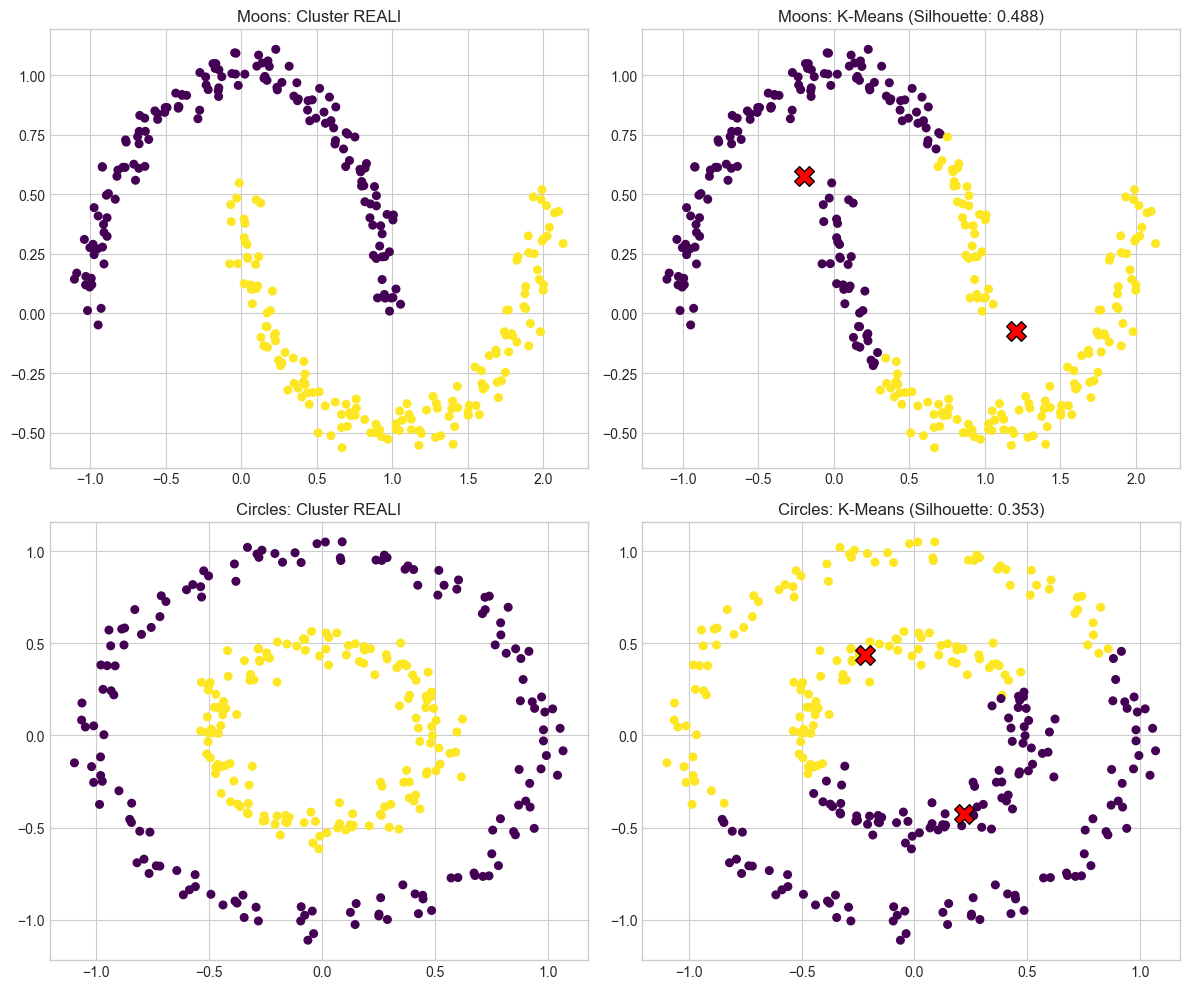

In [15]:
# Applicare K-Means ai dataset moons e circles
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Moons
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_moons = kmeans_moons.fit_predict(X_moons)

axes[0, 0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=30)
axes[0, 0].set_title('Moons: Cluster REALI')

axes[0, 1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons, cmap='viridis', s=30)
axes[0, 1].scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:, 1], 
                   c='red', marker='X', s=200, edgecolors='black')
axes[0, 1].set_title(f'Moons: K-Means (Silhouette: {silhouette_score(X_moons, labels_moons):.3f})')

# Circles
kmeans_circles = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_circles = kmeans_circles.fit_predict(X_circles)

axes[1, 0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', s=30)
axes[1, 0].set_title('Circles: Cluster REALI')

axes[1, 1].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_circles, cmap='viridis', s=30)
axes[1, 1].scatter(kmeans_circles.cluster_centers_[:, 0], kmeans_circles.cluster_centers_[:, 1], 
                   c='red', marker='X', s=200, edgecolors='black')
axes[1, 1].set_title(f'Circles: K-Means (Silhouette: {silhouette_score(X_circles, labels_circles):.3f})')

plt.tight_layout()
plt.show()

**Osservazione:** K-Means fallisce con cluster non sferici! 

Nella prossimo notebook vedremo **DBSCAN**, un algoritmo che gestisce meglio queste situazioni.

---
## 7. Importanza della Standardizzazione

K-Means usa le **distanze** per assegnare i punti ai cluster. Se le features hanno scale diverse, quelle con valori più grandi domineranno.

In [16]:
# Creare un dataset con scale molto diverse
np.random.seed(42)
X_scaled_badly = np.column_stack([
    np.random.randn(200) * 1,      # Feature 1: scala piccola (~-3 a +3)
    np.random.randn(200) * 1000    # Feature 2: scala grande (~-3000 a +3000)
])

# Aggiungere struttura di cluster
X_scaled_badly[:100, 0] += 2
X_scaled_badly[:100, 1] += 2000

print("Range delle features:")
print(f"  Feature 1: [{X_scaled_badly[:, 0].min():.1f}, {X_scaled_badly[:, 0].max():.1f}]")
print(f"  Feature 2: [{X_scaled_badly[:, 1].min():.1f}, {X_scaled_badly[:, 1].max():.1f}]")

Range delle features:
  Feature 1: [-1.9, 3.9]
  Feature 2: [-2123.9, 5852.7]


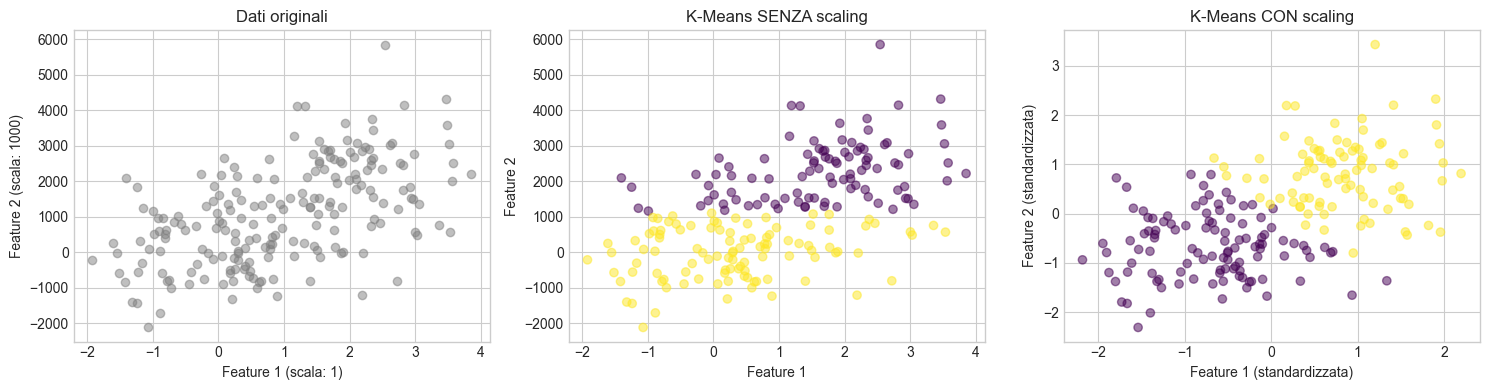

In [17]:
# Preprocessing
from sklearn.preprocessing import StandardScaler

# Confronto: con e senza standardizzazione
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dati originali
axes[0].scatter(X_scaled_badly[:, 0], X_scaled_badly[:, 1], c='gray', alpha=0.5)
axes[0].set_title('Dati originali')
axes[0].set_xlabel('Feature 1 (scala: 1)')
axes[0].set_ylabel('Feature 2 (scala: 1000)')

# K-Means senza standardizzazione
kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X_scaled_badly)
axes[1].scatter(X_scaled_badly[:, 0], X_scaled_badly[:, 1], c=labels_raw, cmap='viridis', alpha=0.5)
axes[1].set_title('K-Means SENZA scaling')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

# K-Means con standardizzazione
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_scaled_badly)

kmeans_scaled = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_standardized)
axes[2].scatter(X_standardized[:, 0], X_standardized[:, 1], c=labels_scaled, cmap='viridis', alpha=0.5)
axes[2].set_title('K-Means CON scaling')
axes[2].set_xlabel('Feature 1 (standardizzata)')
axes[2].set_ylabel('Feature 2 (standardizzata)')

plt.tight_layout()
plt.show()

**Regola:** Standardizza sempre i dati prima di applicare K-Means (e la maggior parte degli algoritmi di clustering)!

---
## 8. Caso Pratico: Segmentazione Clienti

Applichiamo K-Means a un caso reale: segmentare i clienti di un centro commerciale in base al loro comportamento d'acquisto.

In [18]:
# Creare un dataset simulato di clienti
# (In un caso reale, caricheresti i dati da un file)
np.random.seed(42)

n_customers = 200

# Simulare 4 segmenti di clienti
# Segmento 1: Giovani con reddito basso, spesa alta (studenti con genitori ricchi?)
seg1 = np.column_stack([
    np.random.normal(25, # età media del segmento
                     5, # deviazione standard dell'età
                     50 # numero di clienti nel segmento
                     ), # Età
    np.random.normal(30, 10, 50),   # Reddito (k€)
    np.random.normal(70, 15, 50)    # Spending Score (1-100)
])

# Segmento 2: Giovani con reddito basso, spesa bassa
seg2 = np.column_stack([
    np.random.normal(25, 5, 50), # Età
    np.random.normal(30, 10, 50), # Reddito (k€)
    np.random.normal(30, 10, 50) # Spending Score (1-100)
])

# Segmento 3: Adulti con reddito alto, spesa alta
seg3 = np.column_stack([
    np.random.normal(45, 8, 50), # Età
    np.random.normal(80, 15, 50), # Reddito (k€)
    np.random.normal(75, 12, 50) # Spending Score (1-100)
])

# Segmento 4: Adulti con reddito alto, spesa bassa (risparmiatori)
seg4 = np.column_stack([
    np.random.normal(50, 10, 50), # Età
    np.random.normal(85, 12, 50), # Reddito (k€)
    np.random.normal(25, 8, 50) # Spending Score (1-100)
])

# Combinare i segmenti
customers = np.vstack([seg1, seg2, seg3, seg4])

# Creare DataFrame
df_customers = pd.DataFrame(customers, columns=['Età', 'Reddito_Annuo_k', 'Spending_Score'])

# Assicurarsi che i valori siano sensati, dato che li stiamo generando casualmente con distribuzioni normali
# clip limita i valori all'interno di un intervallo specificato, ad esempio l'età tra 18 e 70 anni
# se un cliente ha età 75, verrà portato a 70; se ha età 15, verrà portato a 18
# stessa cosa per reddito e spending score
df_customers['Età'] = df_customers['Età'].clip(18, 70).astype(int)
df_customers['Reddito_Annuo_k'] = df_customers['Reddito_Annuo_k'].clip(15, 150).round(1)
df_customers['Spending_Score'] = df_customers['Spending_Score'].clip(1, 100).astype(int)

print("Prime 10 righe del dataset:")
df_customers.head(10)

Prime 10 righe del dataset:


,Età,Reddito_Annuo_k,Spending_Score
0,27,33.2,48
1,24,26.1,63
2,28,23.2,64
3,32,36.1,57
4,23,40.3,67
5,23,39.3,76
6,32,21.6,98
7,28,26.9,72
8,22,33.3,73
9,27,39.8,68


In [93]:
# Statistiche descrittive
print("Statistiche descrittive:")
df_customers.describe()

Statistiche descrittive:


,Età,Reddito_Annuo_k,Spending_Score
count,200.000000,200.00000,200.000000
mean,35.465000,56.70850,49.195000
std,13.147359,28.01656,25.199445
min,18.000000,15.00000,1.000000
25%,24.000000,30.90000,27.000000
50%,33.500000,53.70000,46.000000
75%,45.250000,81.65000,72.250000
max,70.000000,112.80000,100.000000


In [19]:
# Standardizzare i dati
scaler = StandardScaler()
X_customers = scaler.fit_transform(df_customers)

print(X_customers[:11])

[[-0.64547126 -0.84119866 -0.04754068]
 [-0.87422658 -1.09525615  0.54920425]
 [-0.56921949 -1.19902612  0.58898725]
 [-0.26421239 -0.7374287   0.31050628]
 [-0.95047835 -0.58714117  0.70833624]
 [-0.95047835 -0.62292392  1.0663832 ]
 [-0.26421239 -1.25627851  1.9416091 ]
 [-0.56921949 -1.06662996  0.90725121]
 [-1.02673013 -0.83762039  0.94703421]
 [-0.64547126 -0.60503255  0.74811923]
 [-1.02673013 -1.12746063 -0.32602165]]


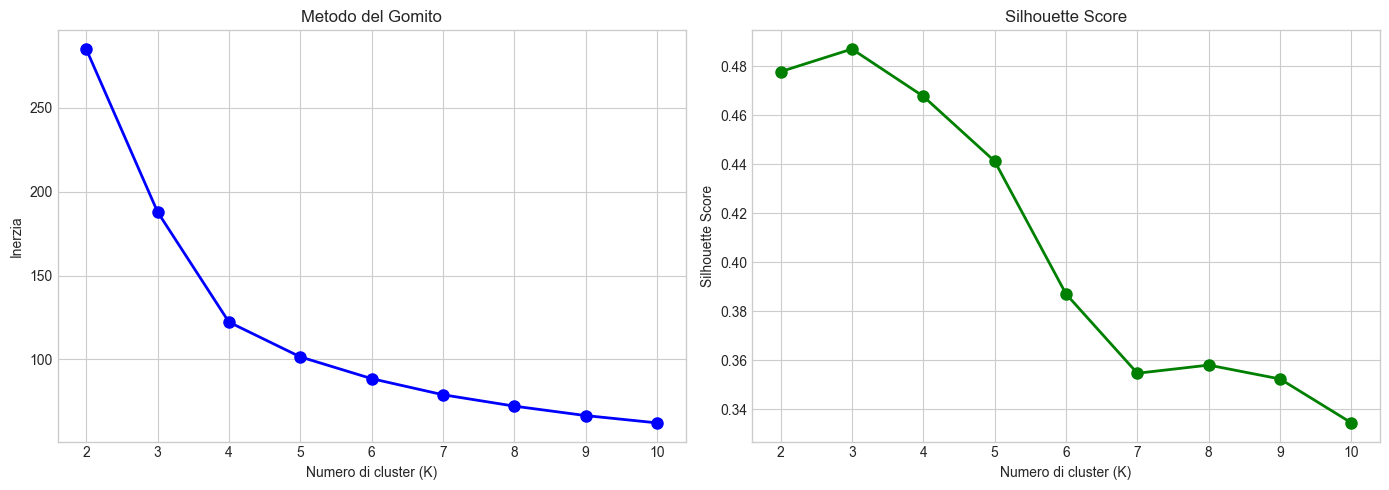


Silhouette scores:
  K=2: 0.478
  K=3: 0.487
  K=4: 0.468
  K=5: 0.441
  K=6: 0.387
  K=7: 0.355
  K=8: 0.358
  K=9: 0.352
  K=10: 0.334


In [98]:
# Standardizzare i dati
scaler = StandardScaler()
X_customers = scaler.fit_transform(df_customers)

# Trovare il K ottimale con Elbow e Silhouette
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_customers)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_customers, labels))

# Visualizzare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero di cluster (K)')
axes[0].set_ylabel('Inerzia')
axes[0].set_title('Metodo del Gomito')
axes[0].set_xticks(list(k_values))

axes[1].plot(k_values, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero di cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, sil in zip(k_values, silhouettes):
    print(f"  K={k}: {sil:.3f}")

In [103]:
# Applicare K-Means con K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_customers['Cluster'] = kmeans_final.fit_predict(X_customers)

# Analizzare i cluster
print("Profilo dei cluster (valori medi):")
cluster_profile = df_customers.groupby('Cluster').mean().round(1)
cluster_profile['N_Clienti'] = df_customers.groupby('Cluster').size()
cluster_profile

Profilo dei cluster (valori medi):


,Età,Reddito_Annuo_k,Spending_Score,N_Clienti
Cluster,,,,
0,44.9,83.8,74.3,48
1,23.7,30.6,73.4,42
2,48.6,81.5,25.3,51
3,24.8,31.9,32.2,59


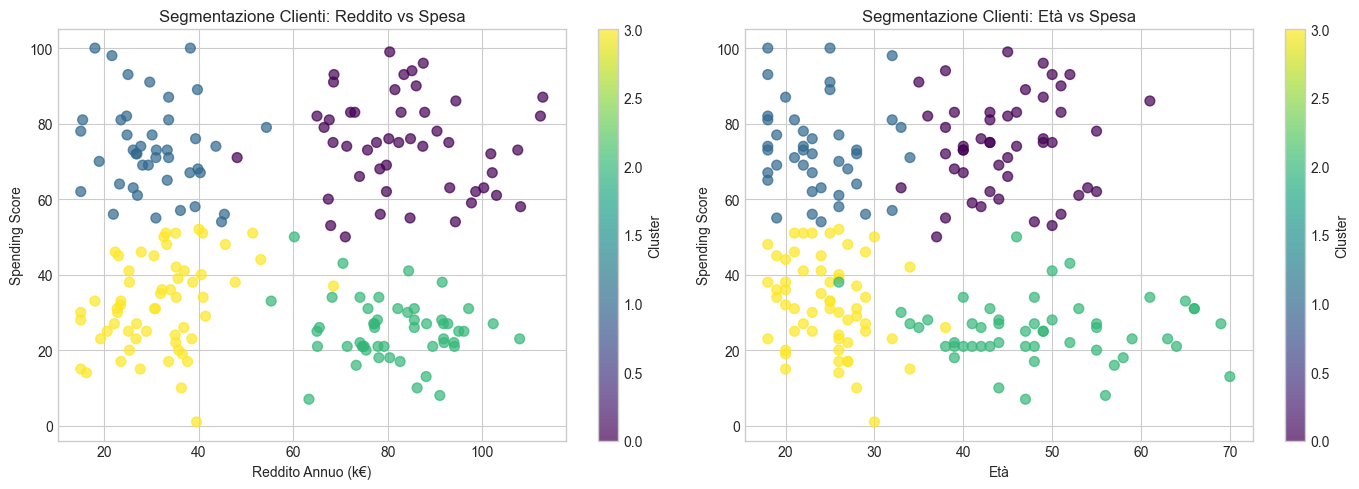

In [104]:
# Visualizzare i cluster
fig = plt.figure(figsize=(14, 5))

# Plot 1: Reddito vs Spending Score
ax1 = fig.add_subplot(121)
scatter1 = ax1.scatter(df_customers['Reddito_Annuo_k'], df_customers['Spending_Score'], 
                       c=df_customers['Cluster'], cmap='viridis', s=50, alpha=0.7)
ax1.set_xlabel('Reddito Annuo (k€)')
ax1.set_ylabel('Spending Score')
ax1.set_title('Segmentazione Clienti: Reddito vs Spesa')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Plot 2: Età vs Spending Score
ax2 = fig.add_subplot(122)
scatter2 = ax2.scatter(df_customers['Età'], df_customers['Spending_Score'], 
                       c=df_customers['Cluster'], cmap='viridis', s=50, alpha=0.7)
ax2.set_xlabel('Età')
ax2.set_ylabel('Spending Score')
ax2.set_title('Segmentazione Clienti: Età vs Spesa')
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.show()

In [105]:
# Interpretazione business dei cluster
print("="*60)
print("INTERPRETAZIONE DEI SEGMENTI DI CLIENTI")
print("="*60)

for cluster_id in sorted(df_customers['Cluster'].unique()):
    subset = df_customers[df_customers['Cluster'] == cluster_id]
    print(f"\n📊 CLUSTER {cluster_id}:")
    print(f"   Clienti: {len(subset)}")
    print(f"   Età media: {subset['Età'].mean():.0f} anni")
    print(f"   Reddito medio: {subset['Reddito_Annuo_k'].mean():.1f}k €")
    print(f"   Spending Score medio: {subset['Spending_Score'].mean():.0f}")

INTERPRETAZIONE DEI SEGMENTI DI CLIENTI

📊 CLUSTER 0:
   Clienti: 48
   Età media: 45 anni
   Reddito medio: 83.8k €
   Spending Score medio: 74

📊 CLUSTER 1:
   Clienti: 42
   Età media: 24 anni
   Reddito medio: 30.6k €
   Spending Score medio: 73

📊 CLUSTER 2:
   Clienti: 51
   Età media: 49 anni
   Reddito medio: 81.5k €
   Spending Score medio: 25

📊 CLUSTER 3:
   Clienti: 59
   Età media: 25 anni
   Reddito medio: 31.9k €
   Spending Score medio: 32


---
## 9. Riepilogo K-Means

| Aspetto | Dettaglio |
|---------|----------|
| **Tipo** | Clustering partizionale |
| **Input richiesto** | Numero di cluster K |
| **Come funziona** | Minimizza la distanza intra-cluster (inerzia) |
| **Punti di forza** | Veloce, scalabile, facile da interpretare |
| **Limitazioni** | Solo cluster sferici, sensibile agli outlier, richiede K |
| **Quando usarlo** | Cluster ben separati, approssimativamente sferici |

**Workflow tipico:**
1. Standardizzare i dati
2. Usare Elbow Method e Silhouette per scegliere K
3. Applicare K-Means
4. Analizzare e interpretare i cluster

---
## 10. Esercizi

### Esercizio 1: K-Means su Iris (senza etichette)

Applica K-Means al dataset Iris **ignorando le etichette** (come se non le avessimo):
1. Carica il dataset e usa solo X (non y)
2. Standardizza i dati
3. Trova il K ottimale con Elbow e Silhouette
4. Applica K-Means con il K scelto
5. Confronta i cluster trovati con le etichette reali (y)

Domanda: K-Means riesce a "scoprire" le 3 specie di Iris?

In [ ]:
# Il tuo codice qui


### Esercizio 2: K-Means su Wine Dataset
Applica K-Means al dataset Wine:

1. Carica il dataset con load_wine()
2. Standardizza i dati
3. Trova il K ottimale con Elbow Method e Silhouette Score
4. Applica K-Means con il K scelto
5. Confronta i cluster trovati con le etichette reali usando una tabella di contingenza (pd.crosstab)

Domanda: K-Means riesce a "scoprire" le 3 varietà di vino?

In [ ]:
# Il tuo codice qui


---
## Soluzioni Esercizi

### Soluzione Esercizio 1

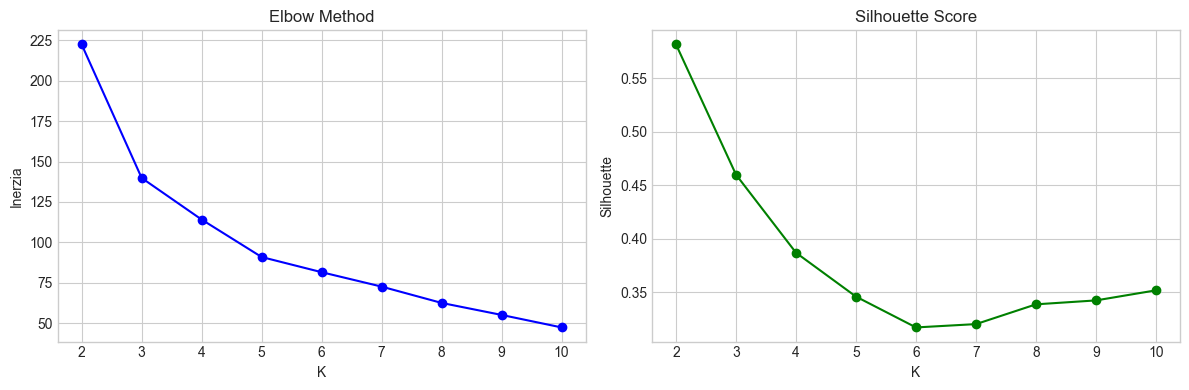


Confronto cluster K-Means vs Specie reali:
                 setosa  versicolor  virginica
Cluster K-Means                               
0                     0          39         14
1                    50           0          0
2                     0          11         36

Silhouette Score: 0.460


In [1]:
# Librerie fondamentali
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Clustering
from sklearn.cluster import KMeans

# Dataset 
from sklearn.datasets import load_iris

# Metriche di valutazione
from sklearn.metrics import silhouette_score

# Preprocessing
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

# 1. Caricare il dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target  # Lo useremo solo per confronto finale

# 2. Standardizzare
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# 3. Trovare K ottimale
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_iris_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_iris_scaled, labels))

# Visualizzare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertias, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inerzia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_values, silhouettes, 'go-')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

# 4. Applicare K-Means con K=3
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_iris = kmeans_iris.fit_predict(X_iris_scaled)

# 5. Confrontare con etichette reali
print("\nConfronto cluster K-Means vs Specie reali:")
comparison = pd.crosstab(labels_iris, y_iris, 
                         rownames=['Cluster K-Means'], 
                         colnames=['Specie reale'])
comparison.columns = iris.target_names
print(comparison)

print(f"\nSilhouette Score: {silhouette_score(X_iris_scaled, labels_iris):.3f}")

### Soluzione Esercizio 2

Campioni: 178, Features: 13
Classi: ['class_0' 'class_1' 'class_2']


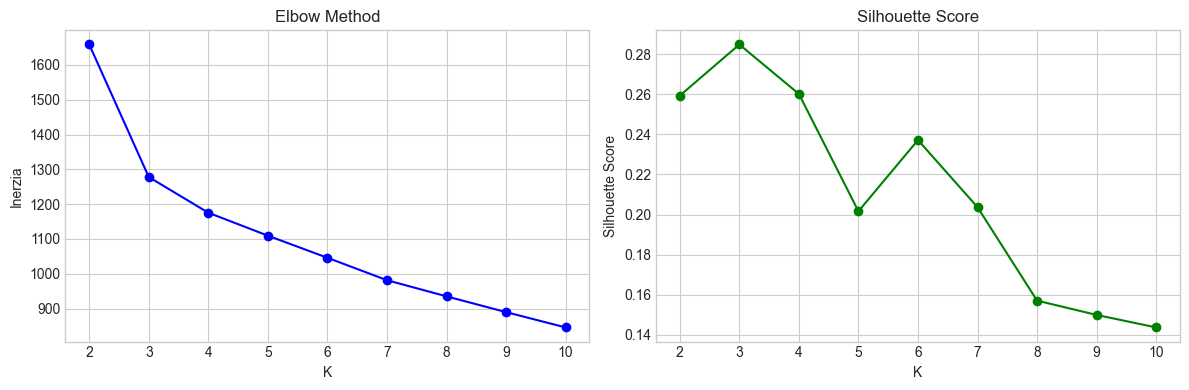


Tabella di contingenza (Cluster vs Varietà reale):
         class_0  class_1  class_2
Cluster                           
0              0       65        0
1              0        3       48
2             59        3        0

Silhouette Score: 0.285


In [4]:
from sklearn.datasets import load_wine

# 1. Caricare il dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print(f"Campioni: {X_wine.shape[0]}, Features: {X_wine.shape[1]}")
print(f"Classi: {wine.target_names}")

# 2. Standardizzare
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

# 3. Trovare K ottimale
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_wine_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_wine_scaled, labels))

# Visualizzare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, inertias, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inerzia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_values))

axes[1].plot(k_values, silhouettes, 'go-')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()

# 4. Applicare K-Means con K=3
kmeans_wine = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_wine = kmeans_wine.fit_predict(X_wine_scaled)

# 5. Confrontare con etichette reali
print("\nTabella di contingenza (Cluster vs Varietà reale):")
ct = pd.crosstab(labels_wine, y_wine, rownames=['Cluster'], colnames=['Varietà'])
ct.columns = wine.target_names
print(ct)

print(f"\nSilhouette Score: {silhouette_score(X_wine_scaled, labels_wine):.3f}")

# K-Medoids

- K-Means: il centroide è la media dei punti (può essere un punto "inventato")
- K-Medoids: il centroide è un punto reale del dataset (il medoid)

Vantaggio: più robusto agli outlier, perché un punto estremo non "trascina" il centro.

K-Medoids non è in sklearn, serve scikit-learn-extra:

``pip install scikit-learn-extra``

``pip install setuptools``

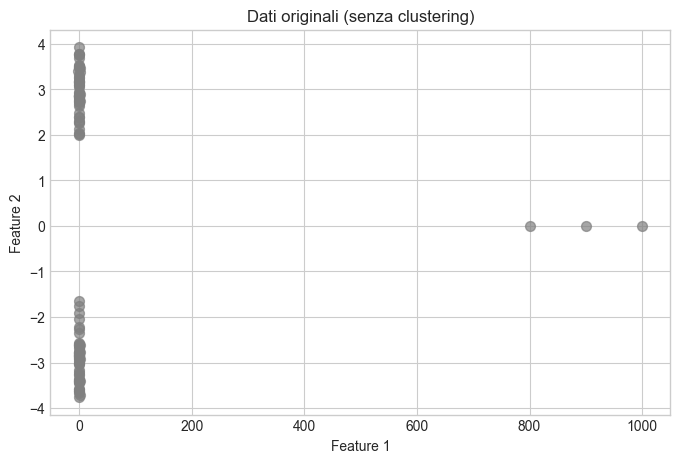

In [5]:
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Cluster compatto
# np.random.randn genera numeri casuali da una distribuzione normale standard (media 0, deviazione standard 1)
# che normalmente sono distribuiti nell'intervallo [-3, +3]
# moltiplicando per 0.5 li spostiamo nell'intervallo [-1.5, +1.5]
# Cluster 1: y > 0 (centrato in y=3)
cluster_1 = np.random.randn(50, 2) * 0.5
cluster_1[:, 1] += 3  # sposta la colonna Y di +3

# Cluster 2: y < 0 (centrato in y=-3)
cluster_2 = np.random.randn(50, 2) * 0.5
cluster_2[:, 1] -= 3  # sposta la colonna Y di -3

# Pochi outlier molto lontani (stessa direzione)
outliers = np.array([[800, 0], [900, 0], [1000, 0]])

# uniamo il tutto
X_demo = np.vstack([cluster_1, cluster_2, outliers])

# Dati prima del clustering
plt.figure(figsize=(8, 5))
plt.scatter(X_demo[:, 0], X_demo[:, 1], c='gray', s=50, alpha=0.7)
plt.title('Dati originali (senza clustering)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

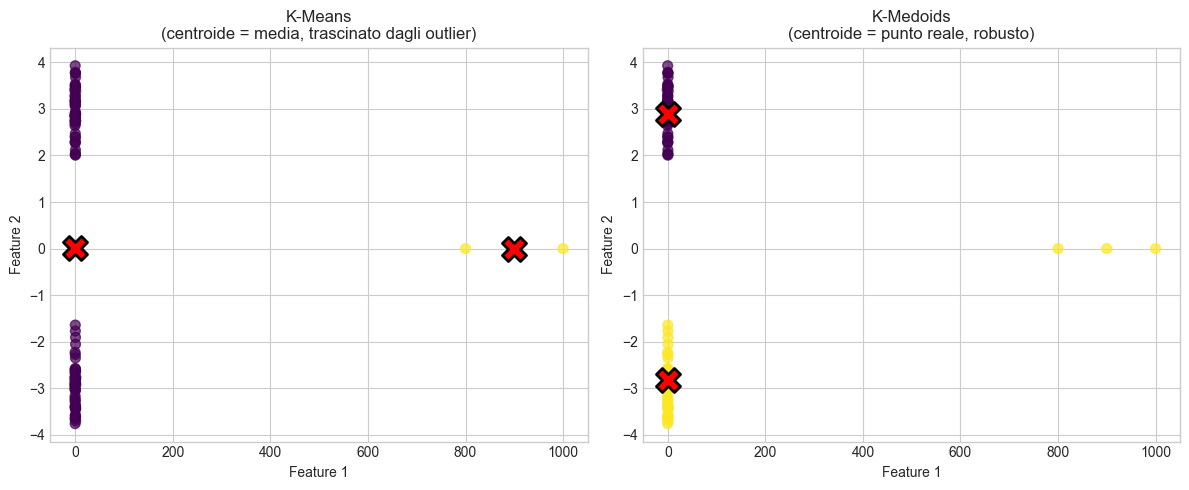

Centroidi K-Means: [[-5.77821274e-02  1.70111622e-02]
 [ 9.00000000e+02  0.00000000e+00]]
Medoid K-Medoids: [[-0.11707669  2.88293152]
 [-0.03855085 -2.82942401]]


In [6]:
# K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_demo)

# K-Medoids
kmedoids = KMedoids(n_clusters=2, random_state=42)
kmedoids.fit(X_demo)

# Confronto visivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means labels_ sono le etichette dei cluster assegnate da K-Means
labels_kmeans = kmeans.labels_
axes[0].scatter(X_demo[:, 0], X_demo[:, 1], c=labels_kmeans, cmap='viridis', s=50, alpha=0.7)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='red', marker='X', s=300, edgecolors='black', linewidths=2)
axes[0].set_title('K-Means\n(centroide = media, trascinato dagli outlier)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# K-Medoids
labels_kmedoids = kmedoids.labels_
axes[1].scatter(X_demo[:, 0], X_demo[:, 1], c=labels_kmedoids, cmap='viridis', s=50, alpha=0.7)
axes[1].scatter(kmedoids.cluster_centers_[:, 0], kmedoids.cluster_centers_[:, 1], 
                c='red', marker='X', s=300, edgecolors='black', linewidths=2)
axes[1].set_title('K-Medoids\n(centroide = punto reale, robusto)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print(f"Centroidi K-Means: {kmeans.cluster_centers_}")
print(f"Medoid K-Medoids: {kmedoids.cluster_centers_}")